<a href="https://colab.research.google.com/github/Ziyi-star/Bachelorarbeit/blob/main/notebooks/training/train_1s_30hz_initial_2class.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os
import pickle
import scipy
import datetime
import numpy as np
import tensorflow as tf
import simclr_utitlities
import transformations
import simclr_models
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import sys

sys.path.append('../../')   # Add parent directory to Python path
working_directory = "../models/"
sys.path.append('../../')
from utils.preprocessing import *
from utils.analyse import *

## 1. Load data

In [3]:
with open('../../data/Field_validation/segmented_data_30hz.pkl', 'rb') as f:
    loaded_data = pickle.load(f)

segments = loaded_data['segments']
segment_info = loaded_data['segment_info']

print(f"Loaded segments shape: {segments.shape}")
print(f"Loaded segment_info length: {len(segment_info)}")

Loaded segments shape: (2496, 30, 3)
Loaded segment_info length: 2496


In [4]:
df_segments_info = pd.DataFrame(segment_info)
df_segments_info.head(10)

,segment_id,start_time,end_time,start_index,curb_activity,curb_scene
0,0,2025-10-21 15:15:40.347,2025-10-21 15:15:41.304,0,0.0,0.0
1,1,2025-10-21 15:15:41.337,2025-10-21 15:15:42.294,30,0.0,0.0
2,2,2025-10-21 15:15:42.327,2025-10-21 15:15:43.284,60,0.0,0.0
3,3,2025-10-21 15:15:43.317,2025-10-21 15:15:44.274,90,0.0,0.0
4,4,2025-10-21 15:15:44.307,2025-10-21 15:15:45.264,120,0.0,0.0
5,5,2025-10-21 15:15:45.297,2025-10-21 15:15:46.254,150,0.0,0.0
6,6,2025-10-21 15:15:46.287,2025-10-21 15:15:47.244,180,0.0,0.0
7,7,2025-10-21 15:15:47.277,2025-10-21 15:15:48.234,210,0.0,0.0
8,8,2025-10-21 15:15:48.267,2025-10-21 15:15:49.224,240,0.0,0.0
9,9,2025-10-21 15:15:49.257,2025-10-21 15:15:50.214,270,0.0,0.0


In [5]:
# Extract curb_scene labels from segment_info
labels = np.array([info['curb_scene'] for info in segment_info])

print(f"Labels shape: {labels.shape}")
print(f"Unique labels: {np.unique(labels)}")


Labels shape: (2496,)
Unique labels: [0. 1.]


In [6]:
# Convert labels to one-hot encoding
labels_one_hot = to_categorical(labels, num_classes=2)

print(f"Original labels shape: {labels.shape}")
print(f"One-hot labels shape: {labels_one_hot.shape}")
print(f"First 5 original labels: {labels[:5]}")
print(f"First 5 one-hot labels:\n{labels_one_hot[:5]}")

Original labels shape: (2496,)
One-hot labels shape: (2496, 2)
First 5 original labels: [0. 0. 0. 0. 0.]
First 5 one-hot labels:
[[1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]
 [1. 0.]]


In [7]:
# Normalize segments
data_normalized = normalize_3d_data(segments)

## 2.Load real world model and evaluate

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(32, 30, 3))
  warnings.warn(msg)


78/78 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


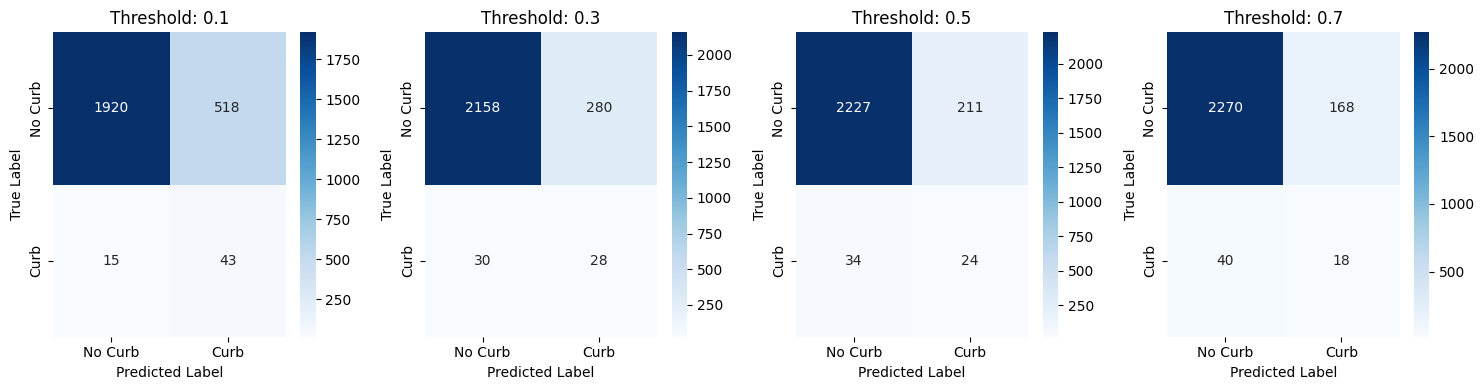


Summary Comparison
Threshold 0.1: Accuracy=0.7865, Precision=0.0766, Recall=0.7414
Threshold 0.3: Accuracy=0.8758, Precision=0.0909, Recall=0.4828
Threshold 0.5: Accuracy=0.9018, Precision=0.1021, Recall=0.4138
Threshold 0.7: Accuracy=0.9167, Precision=0.0968, Recall=0.3103


In [8]:
# Load model
full_eval_best_model_real_world_file_name = "../../models/1s_30hz/2class_unbalanced_real_world_a/20251208-101322_simclr_linear_eval.keras"
full_eval_best_model = tf.keras.models.load_model(full_eval_best_model_real_world_file_name)

# Get predictions
predictions = full_eval_best_model.predict(data_normalized)

# Test different thresholds
thresholds = [0.1,0.3, 0.5, 0.7]
results = {}

fig, axes = plt.subplots(1, len(thresholds), figsize=(15, 4))

for idx, threshold in enumerate(thresholds):
    # Convert predictions to binary labels using threshold
    binary_predictions = (predictions[:, 1] >= threshold).astype(int)
    
    # Generate confusion matrix
    cm = confusion_matrix(labels, binary_predictions)
    
    # Calculate metrics
    tn, fp, fn, tp = cm.ravel()
    accuracy = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    results[threshold] = {
        'confusion_matrix': cm,
        'accuracy': accuracy,
        'precision': precision,
        'recall': recall,
        'f1': f1,
        'tn': tn,
        'fp': fp,
        'fn': fn,
        'tp': tp
    }
    
    # Plot confusion matrix
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], 
                xticklabels=['No Curb', 'Curb'],
                yticklabels=['No Curb', 'Curb'])
    axes[idx].set_title(f'Threshold: {threshold}')
    axes[idx].set_ylabel('True Label')
    axes[idx].set_xlabel('Predicted Label')

plt.tight_layout()
plt.show()

# Print summary comparison
print(f"\n{'='*50}")
print("Summary Comparison")
print(f"{'='*50}")
for threshold in thresholds:
    print(f"Threshold {threshold}: Accuracy={results[threshold]['accuracy']:.4f}, Precision={results[threshold]['precision']:.4f}, Recall={results[threshold]['recall']:.4f}")

## 3. Analyses

In [48]:
# Create a detailed DataFrame for all segments with predictions and segment info
all_segments_details = []

for idx in range(len(labels)):
    segment_detail = {
        'Index': idx,
        'True Label': labels[idx],
        'Predicted Label': binary_predictions[idx],
        'Prediction Score (Class 0)': predictions[idx, 0],
        'Prediction Score (Class 1)': predictions[idx, 1],
        'Start Time': segment_info[idx]['start_time'],
        'End Time': segment_info[idx]['end_time']
    }
    
    all_segments_details.append(segment_detail)

# Convert to DataFrame
df_all_segments = pd.DataFrame(all_segments_details)

# Display the DataFrame
print(f"Total segments: {len(df_all_segments)}")
print(f"\nDataFrame shape: {df_all_segments.shape}")
print(f"\nColumns: {df_all_segments.columns.tolist()}")
print(f"\nFirst 10 rows:")
print(df_all_segments.head(10))

# # Save to CSV
# df_all_segments.to_csv('../../data/Field_validation/all_segments_with_predictions_30hz.csv', index=False)

Total segments: 2496

DataFrame shape: (2496, 7)

Columns: ['Index', 'True Label', 'Predicted Label', 'Prediction Score (Class 0)', 'Prediction Score (Class 1)', 'Start Time', 'End Time']

First 10 rows:
   Index  True Label  Predicted Label  Prediction Score (Class 0)  \
0      0         0.0                0                    0.978082   
1      1         0.0                0                    0.973896   
2      2         0.0                0                    0.987328   
3      3         0.0                0                    0.984247   
4      4         0.0                0                    0.962545   
5      5         0.0                0                    0.971850   
6      6         0.0                0                    0.969941   
7      7         0.0                0                    0.974061   
8      8         0.0                0                    0.973594   
9      9         0.0                0                    0.970153   

   Prediction Score (Class 1)       

Number of True Positives: 24

True Positive Indices:
[ 270  290  292  308  949 1044 1157 1202 1203 1208 1209 1604 1608 1609
 1644 1926 2163 2256 2322 2324 2325 2326 2327 2332]

Detailed True Positive Information:
    Index  True Label  Predicted Label  Prediction Score (Class 0)  \
0     270         1.0                1                    0.308867   
1     290         1.0                1                    0.324624   
2     292         1.0                1                    0.381054   
3     308         1.0                1                    0.001003   
4     949         1.0                1                    0.148447   
5    1044         1.0                1                    0.124103   
6    1157         1.0                1                    0.087175   
7    1202         1.0                1                    0.006606   
8    1203         1.0                1                    0.248982   
9    1208         1.0                1                    0.083622   
10   1209        

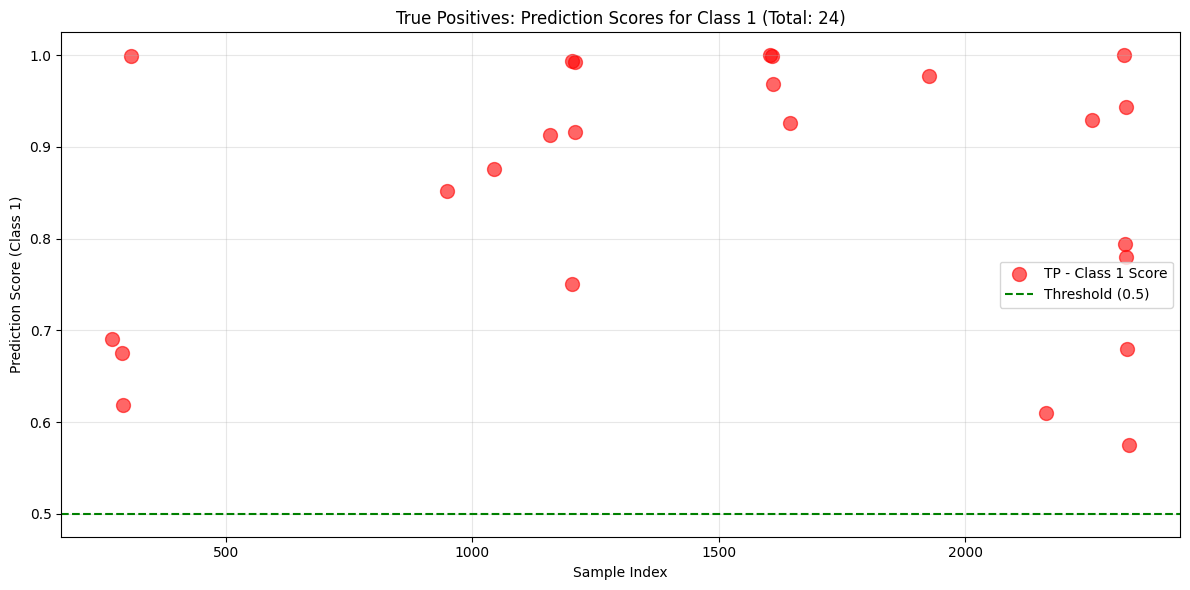

In [10]:
# Use threshold 0.5 (you can change this)
threshold = 0.5
binary_predictions = (predictions[:, 1] >= threshold).astype(int)

# # Find False Negatives: True label is 1, but predicted as 0
# fn_indices = np.where((labels == 1) & (binary_predictions == 0))[0]
# Find True Positives: True label is 1, but predicted as 1
tp_indices = np.where((labels == 1) & (binary_predictions == 1))[0]

print(f"Number of True Positives: {len(tp_indices)}")
print(f"\nTrue Positive Indices:")
print(tp_indices)

# Create a detailed DataFrame for True Positives
tp_details = []
for idx in tp_indices:
    tp_details.append({
        'Index': idx,
        'True Label': labels[idx],
        'Predicted Label': binary_predictions[idx],
        'Prediction Score (Class 0)': predictions[idx, 0],
        'Prediction Score (Class 1)': predictions[idx, 1],
        'Start Time': segment_info[idx]['start_time'],
        'End Time': segment_info[idx]['end_time']
    })

tp_df = pd.DataFrame(tp_details)
print(f"\nDetailed True Positive Information:")
print(tp_df)

# Visualize prediction scores for True Positives
plt.figure(figsize=(12, 6))
plt.scatter(tp_indices, predictions[tp_indices, 1], c='red', label='TP - Class 1 Score', alpha=0.6, s=100)
plt.axhline(y=threshold, color='green', linestyle='--', label=f'Threshold ({threshold})')
plt.xlabel('Sample Index')
plt.ylabel('Prediction Score (Class 1)')
plt.title(f'True Positives: Prediction Scores for Class 1 (Total: {len(tp_indices)})')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Save as CSV
tp_df.to_csv('../../data/Field_validation/true_positives_30hz.csv', index=False)

In [ ]:
# Save to CSV
predictions_df.to_csv('../../data/Field_validation/predictions_30hz_threshold_0.1.csv', index=False)
print(f"Saved predictions with threshold 0.1 to: ../../data/Field_validation/predictions_30hz_threshold_0.1.csv")

In [51]:
df_video = pd.read_csv('../../data/Field_validation/video.csv')
df_video.head()

,NTP,Timestamp,Video,X,Y,Z
0,"2025-10-21, 15:15:42.0410","2025-10-21, 15:15:42.0390",00:00:00.104,-0.161850,-0.621307,-0.760971
1,"2025-10-21, 15:15:42.0420","2025-10-21, 15:15:42.0410",00:00:00.105,-0.166687,-0.623611,-0.760941
2,"2025-10-21, 15:15:42.0490","2025-10-21, 15:15:42.0480",00:00:00.112,-0.161774,-0.620071,-0.765106
3,"2025-10-21, 15:15:42.0520","2025-10-21, 15:15:42.0500",00:00:00.114,-0.156738,-0.621979,-0.765808
4,"2025-10-21, 15:15:42.0530","2025-10-21, 15:15:42.0520",00:00:00.116,-0.152634,-0.622070,-0.766769


In [52]:
# get video positions for each false negative
tp_df = match_false_negatives_to_video(tp_df, df_video, buffer_seconds=0.1)
print(tp_df[['Index', 'Start Time', 'video', 'matched_ntp', 'time_diff']])

    Index              Start Time         video                 matched_ntp  \
0     270 2025-10-21 15:20:07.647  00:04:25.705  2025-10-21 15:20:07.642000   
1     290 2025-10-21 15:20:27.447  00:04:45.505  2025-10-21 15:20:27.443000   
2     292 2025-10-21 15:20:29.427  00:04:47.488  2025-10-21 15:20:29.426000   
3     308 2025-10-21 15:20:45.267  00:05:03.332  2025-10-21 15:20:45.270000   
4     949 2025-10-21 15:31:19.857  00:15:37.921  2025-10-21 15:31:19.858000   
5    1044 2025-10-21 15:32:53.907  00:17:11.970  2025-10-21 15:32:53.908000   
6    1157 2025-10-21 15:34:45.777  00:19:03.841  2025-10-21 15:34:45.779000   
7    1202 2025-10-21 15:35:30.327  00:19:48.389  2025-10-21 15:35:30.326000   
8    1203 2025-10-21 15:35:31.317  00:19:49.375  2025-10-21 15:35:31.312000   
9    1208 2025-10-21 15:35:36.267  00:19:54.327  2025-10-21 15:35:36.264000   
10   1209 2025-10-21 15:35:37.257  00:19:55.323  2025-10-21 15:35:37.261000   
11   1604 2025-10-21 15:42:08.307  00:26:26.367  202

c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:36: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '00:04:25.705' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fn.at[idx, 'video'] = best['Video']
c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:37: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '2025-10-21 15:20:07.642000' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  df_fn.at[idx, 'matched_ntp'] = best['NTP']
c:\Users\liuzi\Desktop\Code\Bachelorarbeit\Bachelorarbeit\notebooks\training\../..\utils\analyse.py:38: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Va

In [53]:
tp_df.to_csv('../../data/Field_validation/true_positives_30hz_with_video.csv', index=False)

## Extra: t-SNE Plots

In [29]:
import sklearn.manifold
import seaborn as sns

In [31]:
perplexity = 30.0

# Then extract the intermediate model
intermediate_model = simclr_models.extract_intermediate_model_from_base_model(full_eval_best_model, intermediate_layer=7)
intermediate_model.summary()

# Continue with your t-SNE code
embeddings = intermediate_model.predict(data_normalized, batch_size=600)
tsne_model = sklearn.manifold.TSNE(perplexity=perplexity, verbose=1, random_state=42)
tsne_projections = tsne_model.fit_transform(embeddings)

Model: "base_model_simclrlinear_layer_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input (InputLayer)              │ (None, 30, 3)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ (None, 30, 32)         │         2,336 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 30, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 30, 64)         │        32,832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 30, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 30, 96)         │        49,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 30, 96)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ (None, 96)             │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 84,416 (329.75 KB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 84,416 (329.75 KB)

1/5 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step

c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(600, 30, 3))
  warnings.warn(msg)
c:\Users\liuzi\miniconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input']
Received: inputs=Tensor(shape=(None, 30, 3))
  warnings.warn(msg)


5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
[t-SNE] Computing 91 nearest neighbors...
[t-SNE] Indexed 2496 samples in 0.000s...


c:\Users\liuzi\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py:136: UserWarning: Could not find the number of physical cores for the following reason:
found 0 physical cores < 1
Returning the number of logical cores instead. You can silence this warning by setting LOKY_MAX_CPU_COUNT to the number of cores you want to use.
  warnings.warn(
  File "c:\Users\liuzi\miniconda3\Lib\site-packages\joblib\externals\loky\backend\context.py", line 282, in _count_physical_cores
    raise ValueError(f"found {cpu_count_physical} physical cores < 1")


[t-SNE] Computed neighbors for 2496 samples in 0.408s...
[t-SNE] Computed conditional probabilities for sample 1000 / 2496
[t-SNE] Computed conditional probabilities for sample 2000 / 2496
[t-SNE] Computed conditional probabilities for sample 2496 / 2496
[t-SNE] Mean sigma: 0.873612
[t-SNE] KL divergence after 250 iterations with early exaggeration: 66.087151
[t-SNE] KL divergence after 1000 iterations: 0.858467


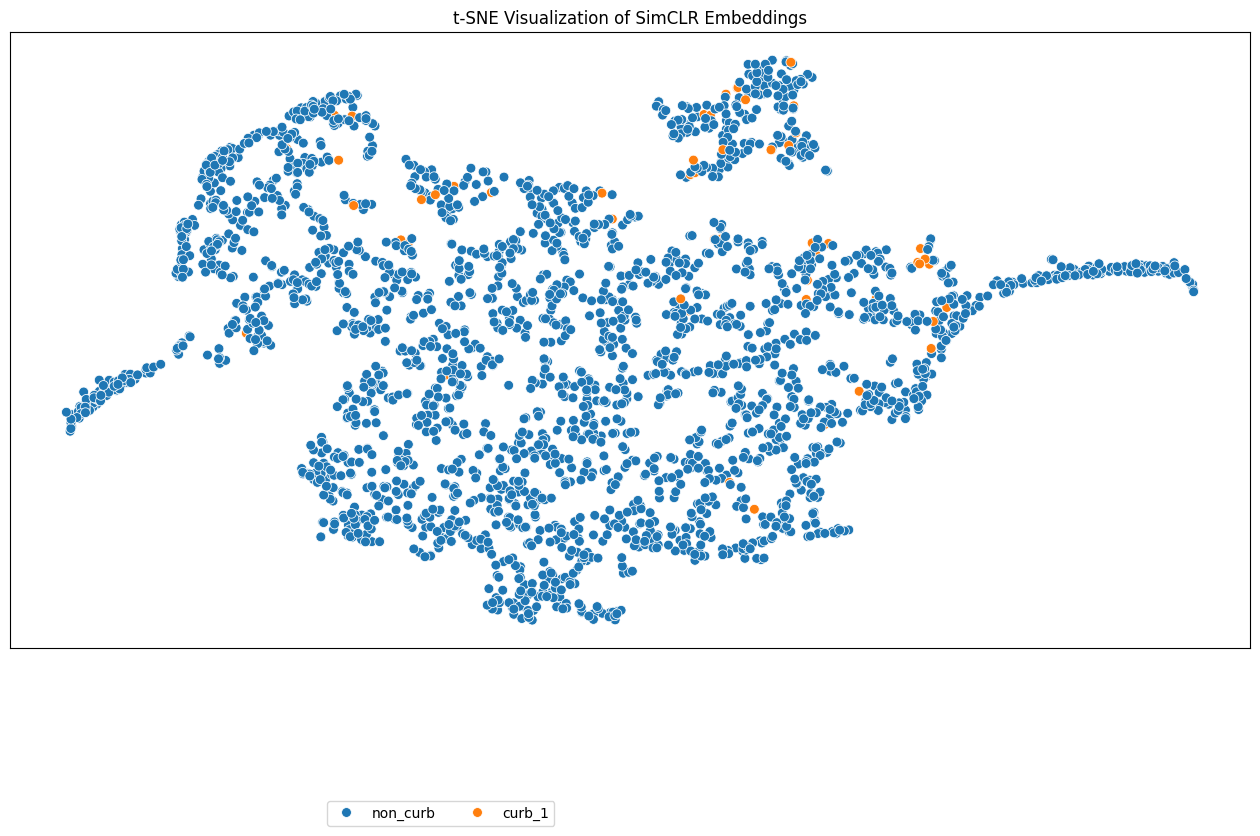

In [32]:
# Define colors
other_class_color = "#1f77b4"  # Blue
curb_1_color = "#ff7f0e"      # Yellow

# Get the true labels (class indices) from the one-hot encoded test labels
labels_argmax = np.argmax(labels_one_hot, axis=1)
unique_labels = np.unique(labels_argmax)

# Create custom color palette
custom_palette = [other_class_color, curb_1_color]  # First color for non_curb (0), second for curb_1 (1)

# Create the t-SNE visualization
plt.figure(figsize=(16,8))
graph = sns.scatterplot(
    x=tsne_projections[:,0], y=tsne_projections[:,1],
    hue=labels_argmax,
    palette=custom_palette,  # Use custom palette instead of "hsv"
    s=50,
    alpha=1.0,
    rasterized=True
)
plt.xticks([], [])
plt.yticks([], [])

plt.title("t-SNE Visualization of SimCLR Embeddings")

# Define your activity names
label_list_full_name = ["non_curb", "curb_1"]

# Update legend with custom colors
try:
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)
    legend = graph.legend_
    if 'label_list_full_name' in globals():
        for j, label in enumerate(unique_labels):
            if label < len(label_list_full_name):
                legend.get_texts()[j].set_text(label_list_full_name[label])
except Exception as e:
    print(f"Warning: Could not customize legend - {e}")
    plt.legend(loc='lower left', bbox_to_anchor=(0.25, -0.3), ncol=2)